# Position of a star

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from scipy.stats import norm
np.random.seed(42)

%matplotlib inline
%config InlineBackend.figure_format='retina'

Generate fake measurements: the underlying process is gaussian with true value mu=1 and sigma=0.2, errors are homoscedastic

In [2]:
N = 5 #five measurements of the position of a star
mu = 1
sigma = 0.2 

x = norm(mu,sigma).rvs(N)
print(x) # each of them is an estimate of the underlying distribution

[1.09934283 0.97234714 1.12953771 1.30460597 0.95316933]


Plot the individual likelihoods separately and plot their product

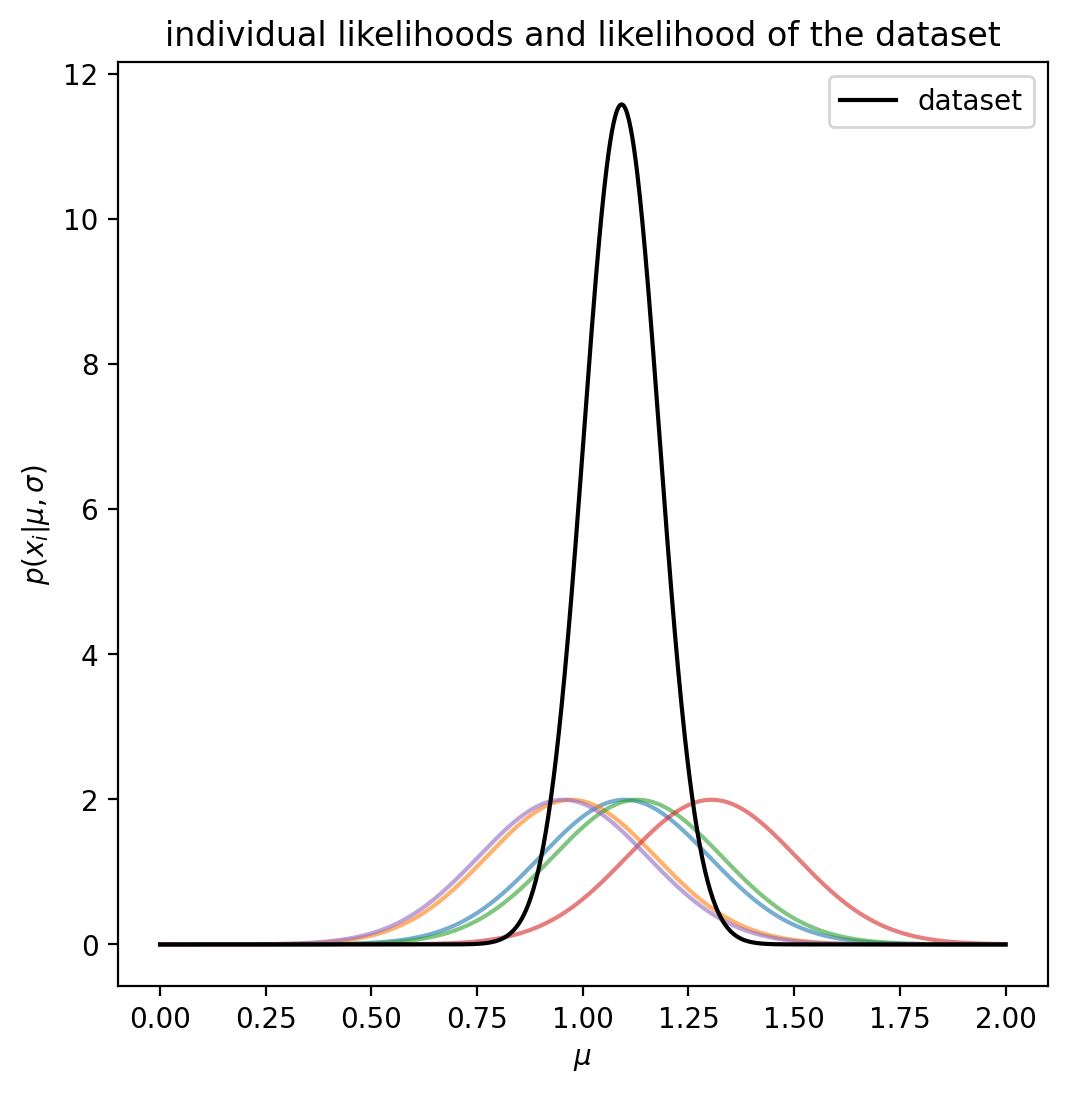

In [3]:
xgrid = np.linspace(0,2,1000)

Li = np.array([norm.pdf(xgrid,loc=center,scale=sigma) for center in x]) # each gaussian centered on the measured value, with sigma=0.2

L = np.prod(Li,axis=0) # likelihood of the full dataset

fig, ax = plt.subplots(figsize=(6, 6))
                       
for likel in Li:
    plt.plot(xgrid, likel, alpha=0.6)
    
plt.plot(xgrid, L, c='black', label='dataset')
plt.xlabel('$\mu$') 
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.title('individual likelihoods and likelihood of the dataset')
plt.legend();

Compute and plot the lnL of the dataset

max of the likelihood: 1.0910910910910911
MLE estimator - mean: 1.0918005948650173
MLE estimator - sigma: 0.08944271909999159


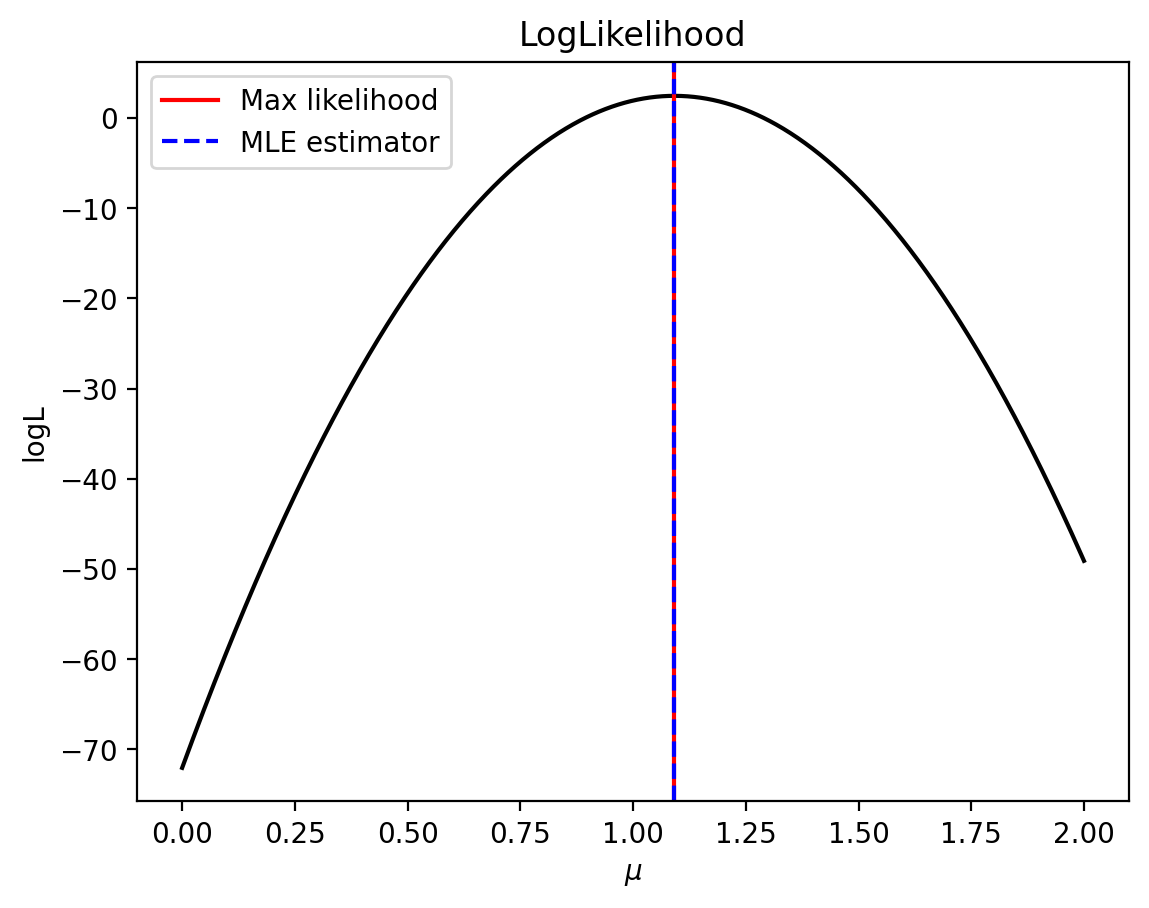

In [4]:
logL = np.sum(np.log(Li),axis=0)
plt.plot(xgrid, logL, color='black')

mu_max = xgrid[np.argmax(logL)]
print('max of the likelihood:', mu_max)

MLE_mean = np.mean(x)
MLE_sigma = sigma/np.sqrt(N)
print('MLE estimator - mean:', MLE_mean)
print('MLE estimator - sigma:', MLE_sigma)

plt.axvline(mu_max,c='red',label='Max likelihood')
plt.axvline(MLE_mean, c='blue',ls='--',label='MLE estimator')
plt.xlabel(r'$\mu$')
plt.ylabel('logL')
plt.title('LogLikelihood')
plt.legend()
plt.show()

Compute the Fisher matrix error

In [5]:
delta_grid = (xgrid[1]-xgrid[0])**2 #delta theta^2
fisher_sigma = -1* np.diff(logL, n=2) / delta_grid
fisher_sigma = 1/np.sqrt(fisher_sigma)[0]

print("Fisher matrix error on estimated mean:", fisher_sigma)
print("MLE estimator error:", MLE_sigma)

Fisher matrix error on estimated mean: 0.08944271910257878
MLE estimator error: 0.08944271909999159


Plot the "measured" likelihood and the numerical likelihood distribution

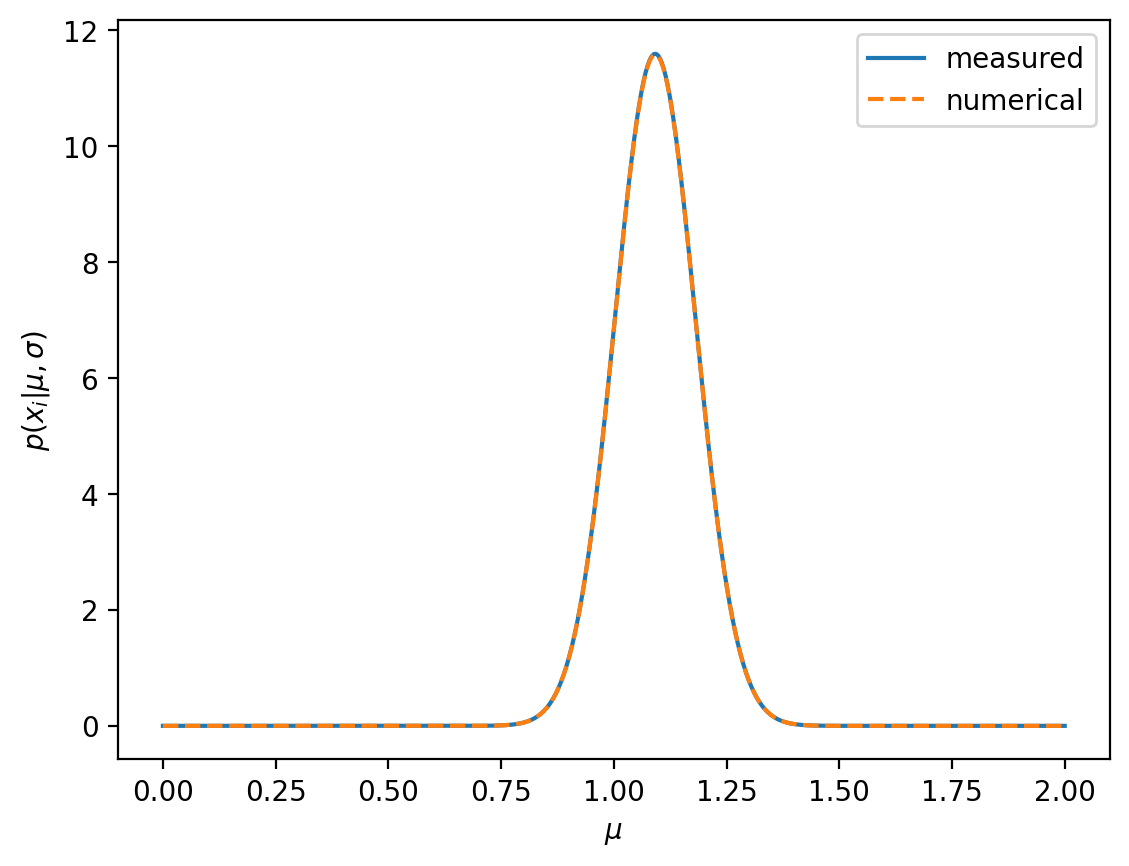

In [6]:
gauss_approx = norm(loc=MLE_mean, scale=MLE_sigma)
plt.plot(xgrid, 2.6*gauss_approx.pdf(xgrid), label='measured')
plt.plot(xgrid, L, ls='dashed', label='numerical')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i|\mu,\sigma)$')
plt.legend()
plt.show()